# [Demo] StateGraph: Schema, Nodes & Edges

O grafo mais simples possível: um estado, um nó, uma aresta. Sem LLM ainda, só a mecânica.

O que vamos ver:
- estado com `TypedDict`;
- nós como funções que leem e escrevem o estado;
- `StateGraph`, `add_node`, `add_edge`, `.compile()`;
- visualizando o grafo;
- o primeiro nó com LLM, usando `MessagesState`;
- validando o estado de verdade com um modelo Pydantic.

## Setup

Carregamos as libs, as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
from typing import TypedDict, Literal
from pydantic import BaseModel
from IPython.display import Image, display
from langchain.messages import SystemMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## Estado: o que viaja entre os nós

O **estado** é o contrato de dados do grafo: um `TypedDict` declara os campos que existem, e cada nó lê e
escreve neles. Começamos sem LLM, só para ver a mecânica.

In [4]:
class RawMessageState(TypedDict):
    raw_message: str
    stripped_message: str
    normalized_message: str

In [11]:
state = RawMessageState(raw_message="Olá, tudo bom?  ")
state

{'raw_message': 'Olá, tudo bom?  '}

## Nós: funções que leem e escrevem o estado

Um nó recebe o estado inteiro e devolve só a parte que quer atualizar. Duas etapas viram dois nós: cada
um lê o campo que a etapa anterior escreveu, e só escreve o seu próprio.

In [8]:
def strip_whitespace(state: RawMessageState) -> dict:
    return {"stripped_message": state["raw_message"].strip()}

In [9]:
def lowercase(state: RawMessageState) -> dict:
    return {"normalized_message": state["stripped_message"].lower()}

In [12]:
strip_whitespace(state)

{'stripped_message': 'Olá, tudo bom?'}

In [13]:
lowercase(strip_whitespace(state))

{'normalized_message': 'olá, tudo bom?'}

## Arestas: conectando os nós

`START` e `END` são marcadores fixos do LangGraph: toda execução começa em `START` e termina em `END`.

In [14]:
builder = StateGraph(RawMessageState)

In [15]:
builder.add_node("strip_whitespace", strip_whitespace)
builder.add_node("lowercase", lowercase)

In [16]:
builder.add_edge(START, "strip_whitespace")
builder.add_edge("strip_whitespace", "lowercase")
builder.add_edge("lowercase", END)

In [17]:
graph = builder.compile()

## Visualizando o grafo

Compilado, o grafo pode desenhar a si mesmo.

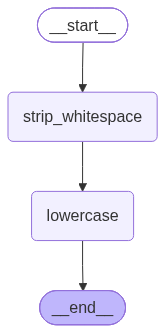

In [18]:
display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [19]:
graph.invoke(
    {
        "raw_message": "  Bom Dia, Preciso De Uma Consulta  "
     }
)

{'raw_message': '  Bom Dia, Preciso De Uma Consulta  ',
 'stripped_message': 'Bom Dia, Preciso De Uma Consulta',
 'normalized_message': 'bom dia, preciso de uma consulta'}

## MessagesState: o estado pronto para conversas

A maioria das aplicações com LLM gira em torno de uma lista de mensagens. Em vez de declarar isso à mão
toda vez, o LangGraph já traz `MessagesState`: um `TypedDict` pronto, com uma chave `messages`. Um nó que
usa o modelo só precisa ler `state["messages"]` e devolver a resposta.

In [20]:
def answer(state: MessagesState) -> dict:
    return {"messages": model.invoke(state["messages"])}

In [21]:
builder = StateGraph(MessagesState)
builder.add_node("answer", answer)
builder.add_edge(START, "answer")
builder.add_edge("answer", END)

In [22]:
graph = builder.compile()

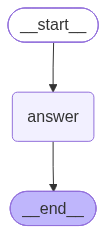

In [23]:
display(Image(graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

In [24]:
system_message = SystemMessage("Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.")
response = graph.invoke({"messages": [system_message, HumanMessage("Vocês atendem cardiologia?")]})

In [25]:
print(response["messages"][-1].content)

Sim, atendemos cardiologia. Se precisar de mais informações ou agendar uma consulta, estamos à disposição!


In [26]:
response["messages"]

[SystemMessage(content='Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.', additional_kwargs={}, response_metadata={}, id='8c4b65a6-c137-4303-b150-50402d8c26bf'),
 HumanMessage(content='Vocês atendem cardiologia?', additional_kwargs={}, response_metadata={}, id='0f59fd5e-75a0-4ad1-96d2-c71979fc9e28'),
 AIMessage(content='Sim, atendemos cardiologia. Se precisar de mais informações ou agendar uma consulta, estamos à disposição!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 39, 'total_tokens': 61, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_9709ac0e8b', 'id': 'chatcmpl-EF3gGQB6ebsdBUHM3z6vUOqa6VJWi', 'servic

## Validação: Pydantic no lugar do TypedDict

Um `TypedDict` é só uma dica de tipo: nada impede um valor fora do esperado de entrar no estado em tempo
de execução. Um modelo Pydantic usado como schema do estado valida de verdade, na entrada do primeiro nó.

In [27]:
class IntakeState(BaseModel):
    urgency: Literal["baixa", "media", "alta"]

Um detalhe muda dentro do nó: um estado Pydantic é lido por atributo (`state.urgency`), não por chave
(`state["urgency"]`) como nos exemplos com `TypedDict`.

In [28]:
def log_intake(state: IntakeState) -> dict:
    print(f"Prioridade registrada: {state.urgency}")
    return {}

In [29]:
intake_builder = StateGraph(IntakeState)
intake_builder.add_node("log_intake", log_intake)
intake_builder.add_edge(START, "log_intake")
intake_builder.add_edge("log_intake", END)

In [30]:
intake_graph = intake_builder.compile()

Uma entrada válida passa direto.

In [31]:
intake_graph.invoke({"urgency": "alta"})

Prioridade registrada: alta


{'urgency': 'alta'}

Uma entrada fora do conjunto permitido é rejeitada antes de qualquer nó rodar.

In [32]:
try:
    intake_graph.invoke({"urgency": "muito urgente"})
except Exception as error:
    print(error)

1 validation error for IntakeState
urgency
  Input should be 'baixa', 'media' or 'alta' [type=literal_error, input_value='muito urgente', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/literal_error


Essa validação acontece só na entrada do primeiro nó, não em cada transição do grafo. Ainda assim, já
barra o erro na porta de entrada, em vez de deixá-lo se espalhar silenciosamente pelo resto do fluxo.

## Takeaway

Estado, um nó, e duas arestas: essa é a mecânica inteira de um `StateGraph`. O primeiro fluxo linear de
atendimento já está de pé, e agora também dá para exigir que o estado chegue validado, com Pydantic.